Notebook to create dataset ready for network usage

In [1]:
from datasets import load_dataset, DatasetDict, Dataset
from torch.utils.data import DataLoader
from PIL import Image
import utils as ut

2024-07-19 09:47:51.859411: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-19 09:47:51.889037: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-19 09:47:51.889059: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-19 09:47:51.889803: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-19 09:47:51.894770: I tensorflow/core/platform/cpu_feature_guar

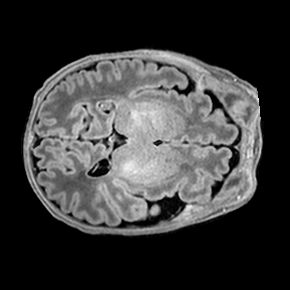

In [2]:
hf_dataset = load_dataset("agucci/mri-sym2")
display(hf_dataset['train'][0]['image'])

In [3]:
def cut_align(image, line, show=False):
    """
    Given an image and line annotation from the dataset, 
    remove background, segment, rotate and cut the two halves.
    Returns halves from the same angle.
    """
    edge_points = ut.non_zeros(image, plot=False)
    transparent_img = ut.segment2(image, edge_points)
    rotated_img = ut.rotate(transparent_img, line, show_line=False)
    slice1, slice2 = ut.slice2(rotated_img)
    slice1 = slice1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT)
    slice1, slice2 = slice1.resize((290, 145)), slice2.resize((290, 145))

    if show:
        display(slice1) # bottom half
        display(slice2) # top

    return slice1, slice2

def transforms(examples):
    # careful with the conversion here
    # resize migth be needed on other datasets
    list_slices = [cut_align(im.convert("L"), line) for im, line in zip(examples["image"], examples["line"])]
    examples["slice1"], examples["slice2"] = [i[0] for i in list_slices], [i[1] for i in list_slices]
    # examples["image_convert"] = [image.convert("L").resize((290, 290)) for image in examples["image"]]

    return examples

Final

In [4]:
hf_dataset = load_dataset("agucci/mri-sym2")

def siamese_noise_dataset(test_size=0.2, shuffle=False):
    """
    T1 only here
    """
    # T1 
    dst1 = hf_dataset['train'].map(transforms, batched=True)
    # noise every other sample
    noise_slice1_t1 = [ut.add_noise(im, rgb=True) if i%2 else im for i, im in enumerate(dst1['slice1'])]
    labels_t1 = [1 if i%2 else 0 for i in range(len(dst1['slice1']))]

    dst1_ = Dataset.from_dict({
        'slice1': noise_slice1_t1,
        'slice2': dst1['slice2'],
        'label': labels_t1
    })

    # splits 
    dst1_traintestval = dst1_.train_test_split(test_size=test_size, shuffle = shuffle)
    dst1_testval = dst1_traintestval['test'].train_test_split(test_size=0.5, shuffle = False)

    dst1_final = DatasetDict({
        'train': dst1_traintestval['train'],
        'test': dst1_testval['test'],
        'valid': dst1_testval['train']})

    return dst1_final

In [5]:
ds_1 = siamese_noise_dataset(shuffle=False)

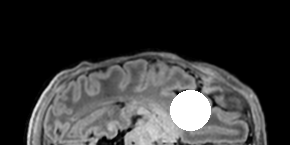

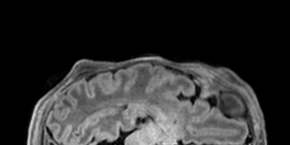

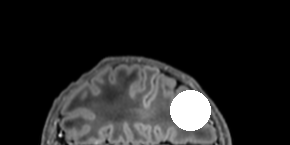

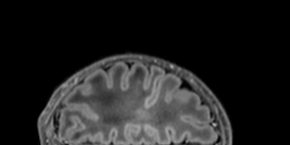

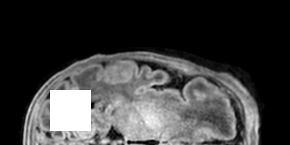

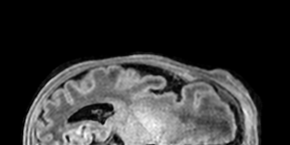

In [6]:
i = 11

display(ds_1['train'][i]['slice1'])
display(ds_1['train'][i]['slice2'])
display(ds_1['test'][i]['slice1'])
display(ds_1['test'][i]['slice2'])
display(ds_1['valid'][i]['slice1'])
display(ds_1['valid'][i]['slice2'])

To use with torch

In [7]:
# dst1_val_exp = dst1_val.remove_columns(["image", "line", "rad_score", "session"])
loader = DataLoader(ds_1['train'].with_format("torch"), batch_size=32)
[i for i in loader][0]['label'][:5]

tensor([0, 1, 0, 1, 0])

**SHUFFLE NEEDED**